# HUPA-UCM patient 27: forecasts and GARCH error bands over the whole recording

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks_3" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import hupa, plotting
from azt1d import reference as ref
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc

plotting.apply_style()

SUBJECT_ID = 27
DAYS_PER_ROW = 10             # the test period is drawn as stacked rows of this many days
STEPS_PER_DAY = 24 * 60 // ref.CGM_INTERVAL_MINUTES
BAND_LEVELS = (0.90, 0.80, 0.55)          # widest first so the narrower ones draw on top
BAND_ALPHA = {0.90: 0.14, 0.80: 0.26, 0.55: 0.42}
CKPT_ROOT = PROJECT_ROOT / "data" / "processed" / "checkpoints"
MODELS = {
    "No error weighted": ("hupa_ucm_cnn_lstm_v0", plotting.CATEGORICAL[0]),
    "Standard error weighted": ("hupa_ucm_cnn_lstm_v1", plotting.CATEGORICAL[1]),
}

df_subject = hupa.load_subject(SUBJECT_ID, PROJECT_ROOT / hupa.DEFAULT_DIR)

# Validation windows are the calibration data for the bands; the test windows are the held-out
# period everything is drawn on. Bands are fitted on calibration residuals only.
frames, engines, cal_frames = {}, {}, {}
for name, (run, _) in MODELS.items():
    res = ckpt.load_result(CKPT_ROOT / run, SUBJECT_ID)
    val, test = unc.forecast_frames(res, df_subject)
    assert unc.matches_stored_predictions(test, res) < 0.05
    cal_frames[name], frames[name] = val, test
    engines[name] = unc.BandEngine(val, test, analogs=False)

actual = frames["No error weighted"].actual
time = pd.to_datetime(frames["No error weighted"].target_time)

## 1. The whole recording

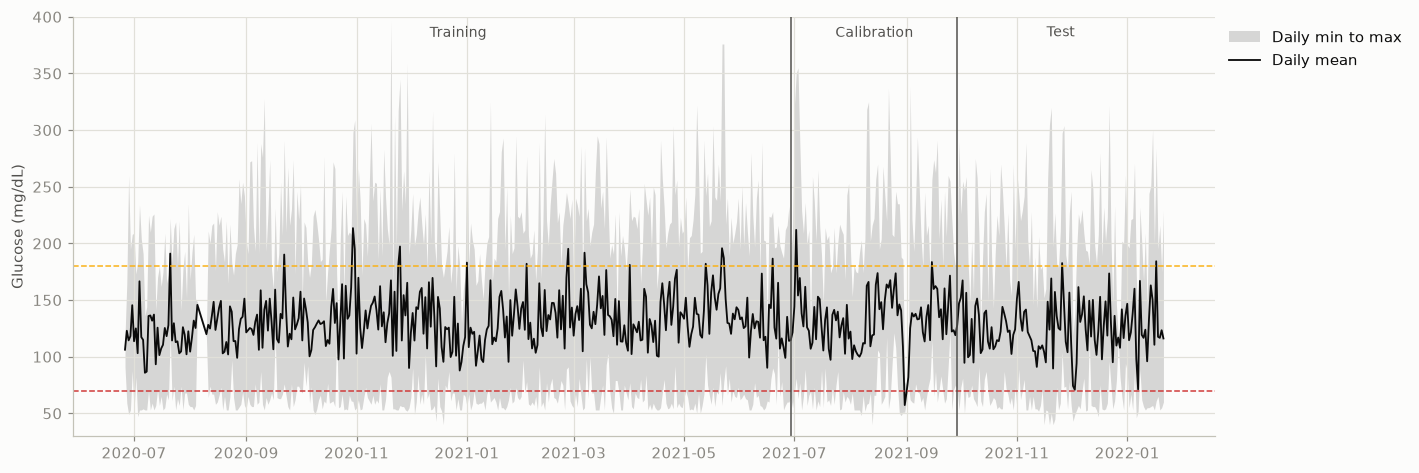

In [2]:
cgm = df_subject.set_index(ref.EVENT_DATETIME)[ref.CGM]
daily = cgm.resample("D").agg(["min", "mean", "max"])
calibration_start = pd.to_datetime(cal_frames["No error weighted"].target_time[0])
test_start = time[0]

fig, ax = plt.subplots(figsize=(13, 4.4))
ax.fill_between(daily.index, daily["min"], daily["max"], color=plotting.INK_SECONDARY, alpha=0.22, linewidth=0, label="Daily min to max")
ax.plot(daily.index, daily["mean"], color=plotting.INK_PRIMARY, linewidth=1.2, label="Daily mean")
ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
for boundary in (calibration_start, test_start):
    ax.axvline(boundary, color=plotting.INK_SECONDARY, linewidth=1)
for label, left, right in (("Training", daily.index[0], calibration_start),
                           ("Calibration", calibration_start, test_start),
                           ("Test", test_start, daily.index[-1])):
    ax.text(left + (right - left) / 2, 392, label, ha="center", va="top", fontsize=9, color=plotting.INK_SECONDARY)
ax.set_ylim(30, 400)
ax.set_ylabel("Glucose (mg/dL)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
plt.show()

## 2. Actual vs. no error weighted vs. standard error weighted

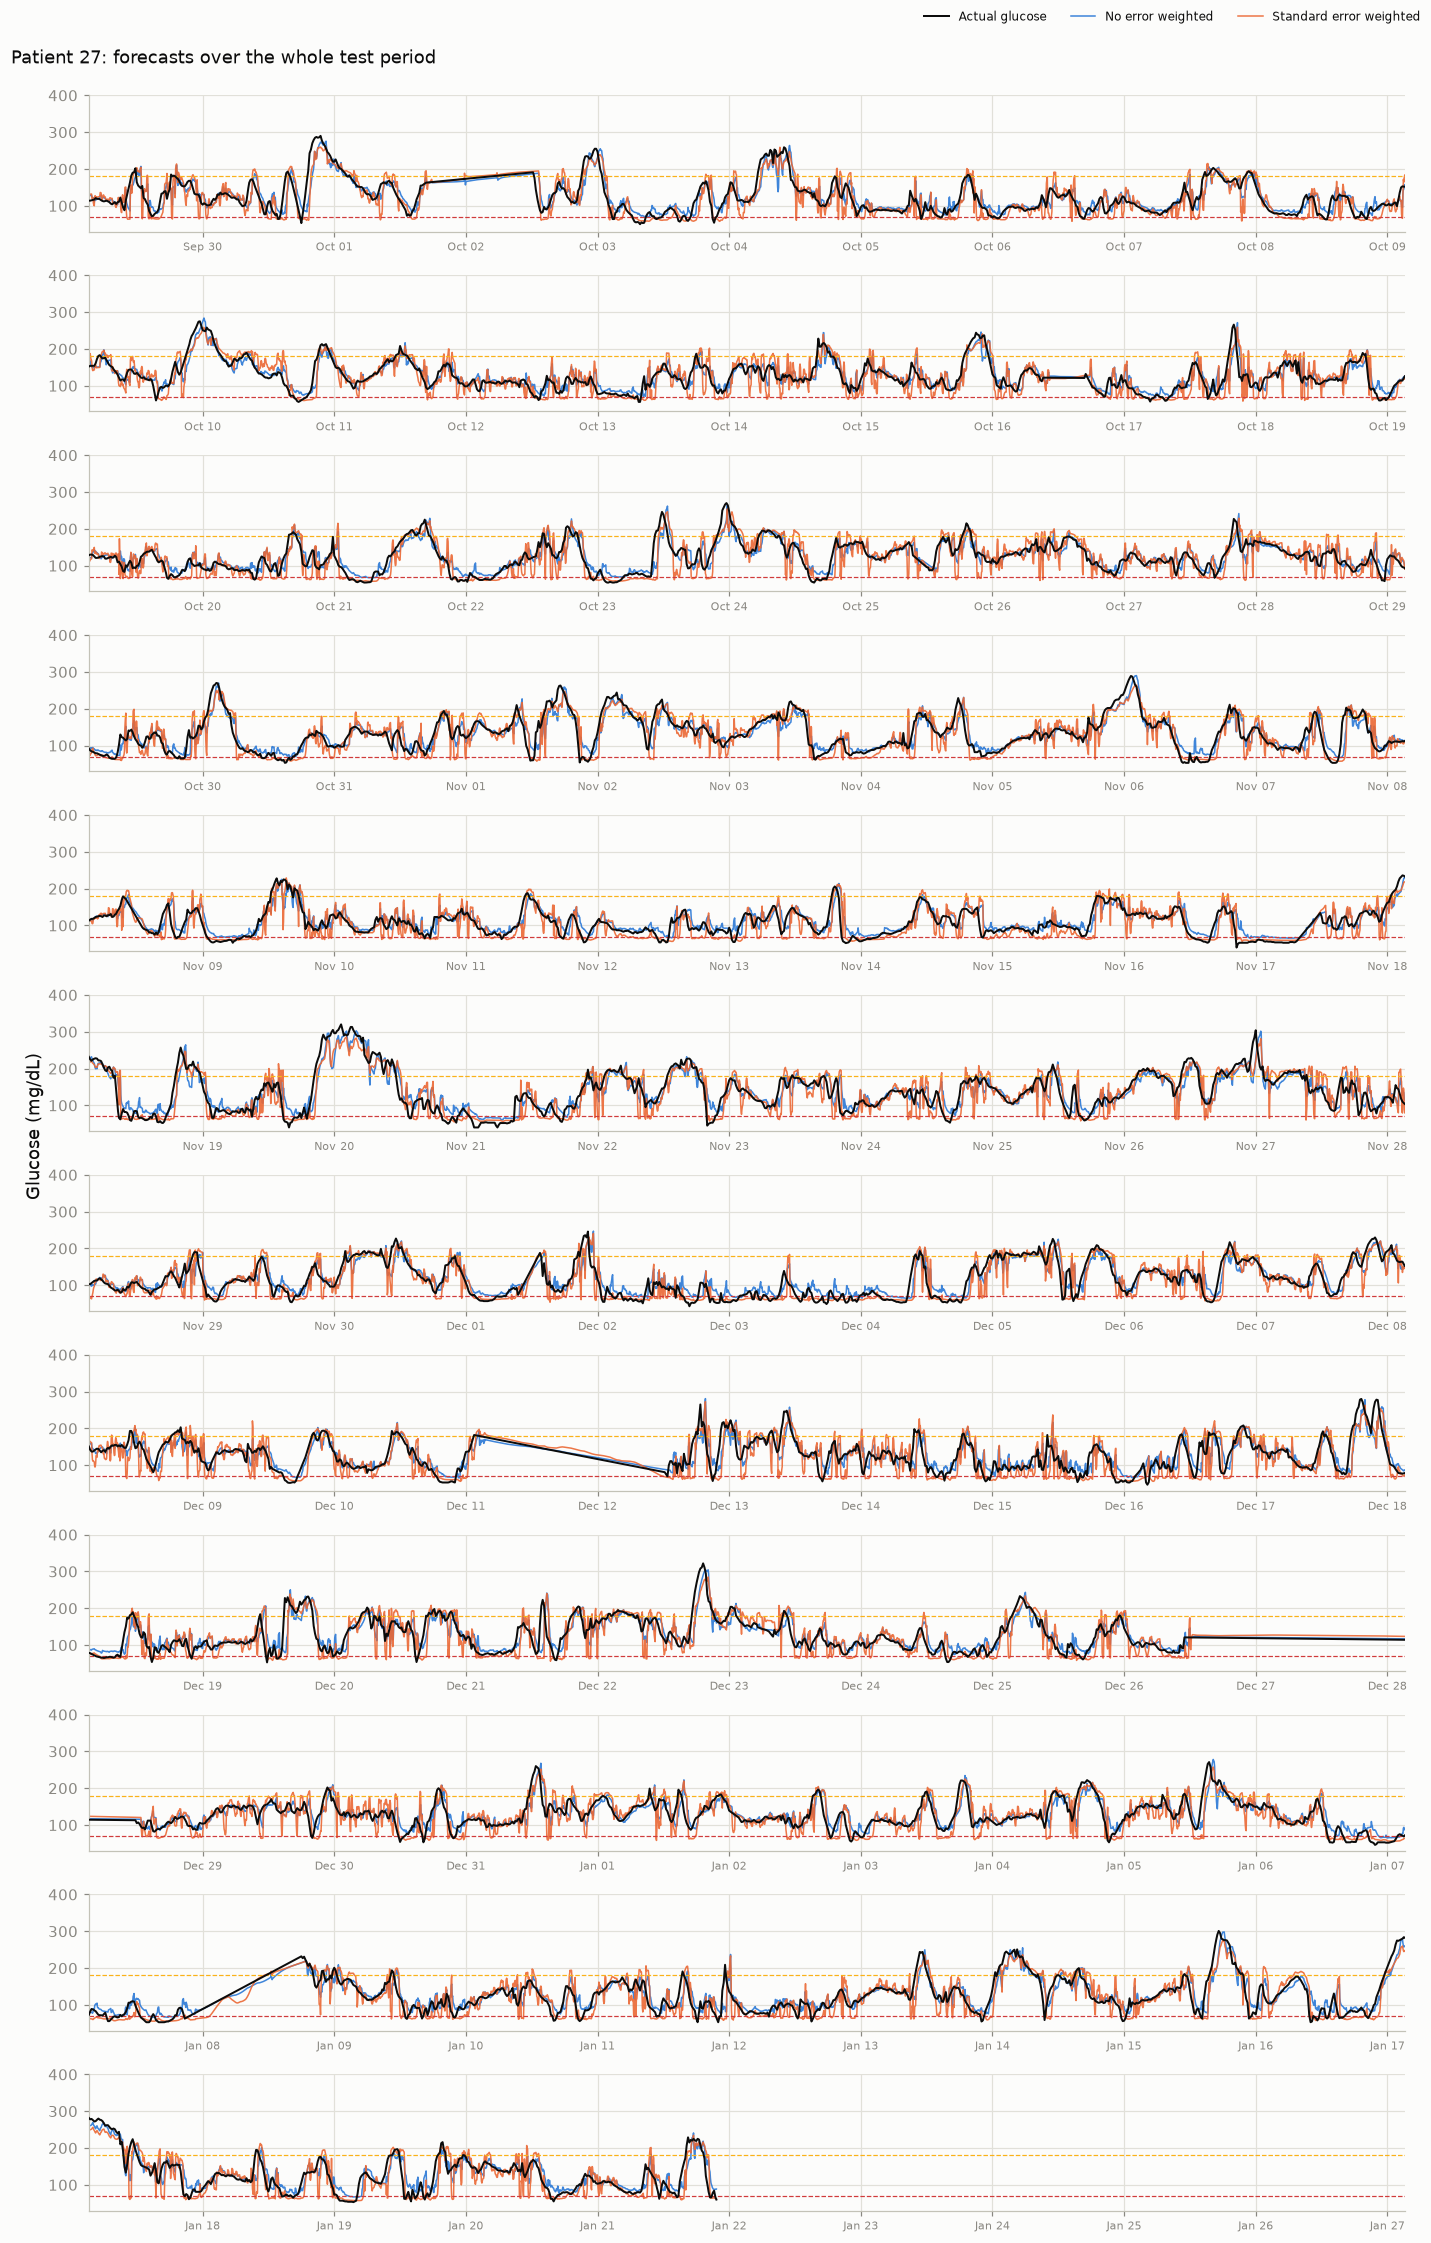

In [3]:
def strip_chart(draw, suptitle):
    """The whole test period as stacked rows of DAYS_PER_ROW days. draw(ax, rows) fills one row."""
    n, step = len(actual), DAYS_PER_ROW * STEPS_PER_DAY
    starts = list(range(0, n, step))
    fig, axes = plt.subplots(len(starts), 1, figsize=(13, 1.7 * len(starts)), sharey=True)
    for ax, a in zip(axes, starts):
        draw(ax, slice(a, min(a + step, n)))
        ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=0.8)
        ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=0.8)
        ax.set_xlim(time[a], time[a] + pd.Timedelta(days=DAYS_PER_ROW))
        ax.set_ylim(30, 400)
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.tick_params(axis="x", labelsize=7)
    fig.supylabel("Glucose (mg/dL)")
    fig.suptitle(suptitle, x=0.01, ha="left")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=6, frameon=False, fontsize=8)
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()


def draw_forecasts(ax, rows):
    ax.plot(time[rows], actual[rows], color=plotting.INK_PRIMARY, linewidth=1.3, label="Actual glucose", zorder=5)
    for name, (_, color) in MODELS.items():
        ax.plot(time[rows], frames[name].pred[rows], color=color, linewidth=1.0, alpha=0.9, label=name)


strip_chart(draw_forecasts, f"Patient {SUBJECT_ID}: forecasts over the whole test period")

## 3. GARCH error bands: no error weighted

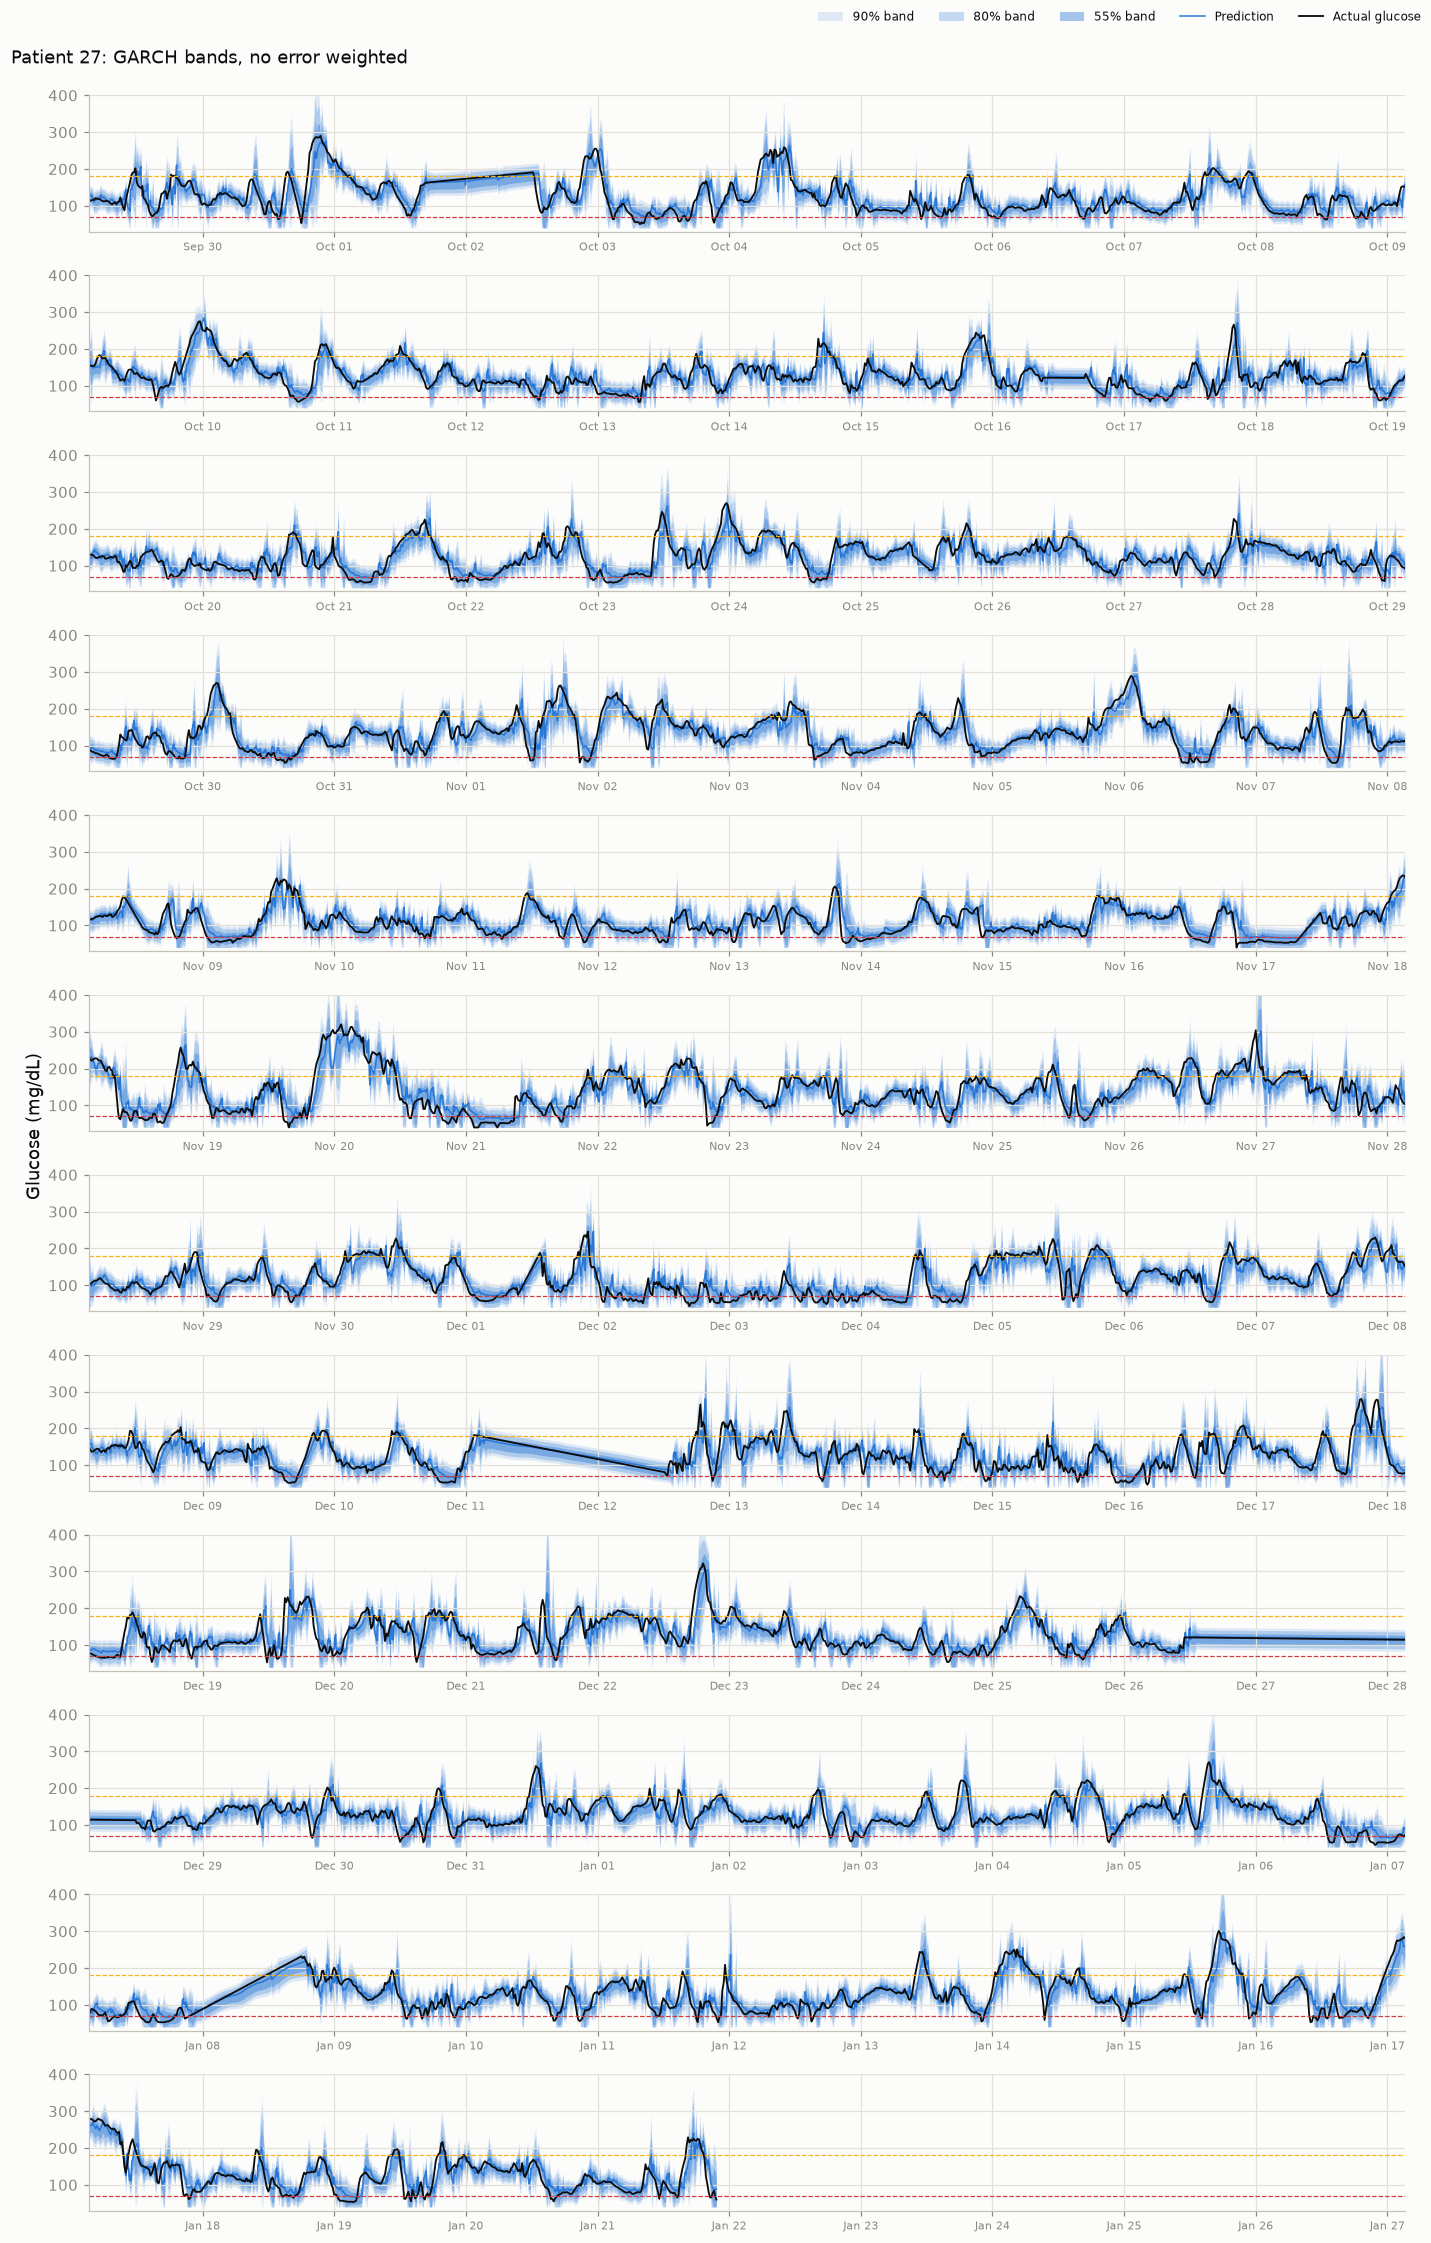

In [4]:
def band_drawer(name):
    color = MODELS[name][1]

    def draw(ax, rows):
        for level in BAND_LEVELS:
            lo, hi = engines[name].bands("GARCH", level)
            ax.fill_between(time[rows], lo[rows], hi[rows], color=color, alpha=BAND_ALPHA[level], linewidth=0,
                            label=f"{int(level * 100)}% band")
        ax.plot(time[rows], frames[name].pred[rows], color=color, linewidth=1.0, label="Prediction")
        ax.plot(time[rows], actual[rows], color=plotting.INK_PRIMARY, linewidth=1.2, label="Actual glucose")

    return draw


strip_chart(band_drawer("No error weighted"), f"Patient {SUBJECT_ID}: GARCH bands, no error weighted")

## 4. GARCH error bands: standard error weighted

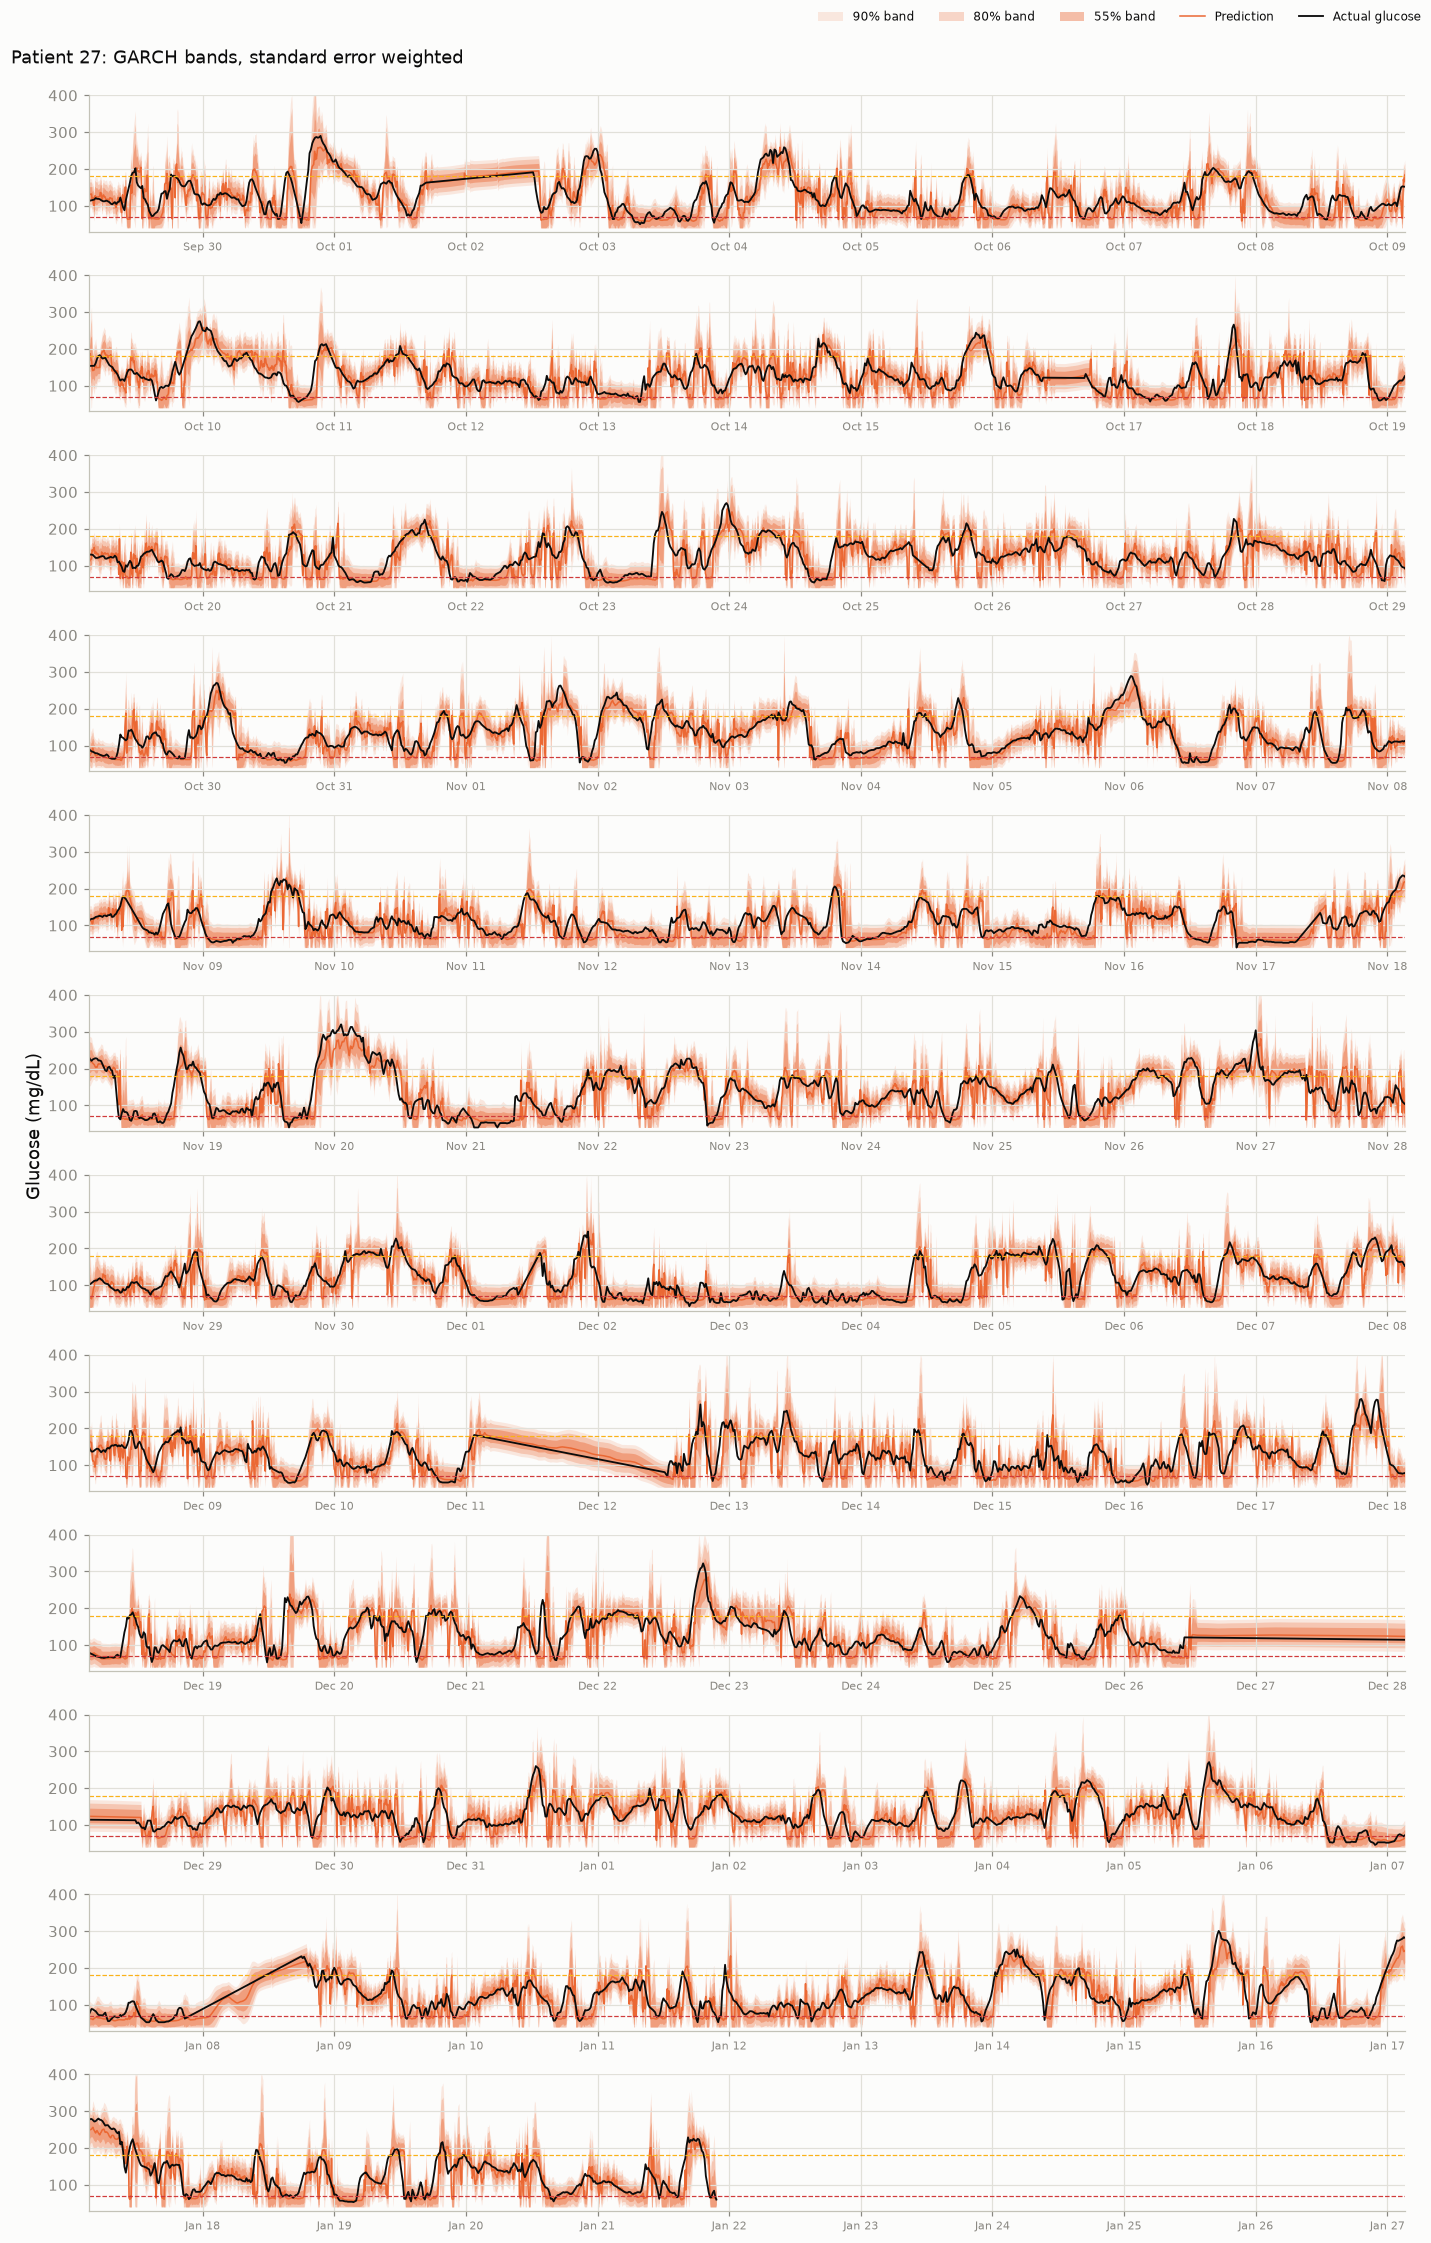

In [5]:
strip_chart(band_drawer("Standard error weighted"), f"Patient {SUBJECT_ID}: GARCH bands, standard error weighted")